# IPL Match Analysis
Exploring match-level trends across 1100 IPL matches (2008–2024) — team dominance,
toss impact, win margins, and standout performers.

## 1. Setup

In [ ]:
from ctypes.macholib.dyld import dyld_default_search

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.pyplot import grid

merge = pd.read_csv("merged_data.csv")
match = pd.read_csv("corrected_data.csv")
delivery = pd.read_csv(r"C:\Users\Parth\OneDrive\Desktop\deliveries.csv")

sns.set_theme(style = "whitegrid")
plt.rcParams["figure.figsize"] = (12,5)

## 2. Team Win Analysis
Which teams have won the most matches across IPL history? Filtering out no-result
matches (8 rows) first since they have no winner.

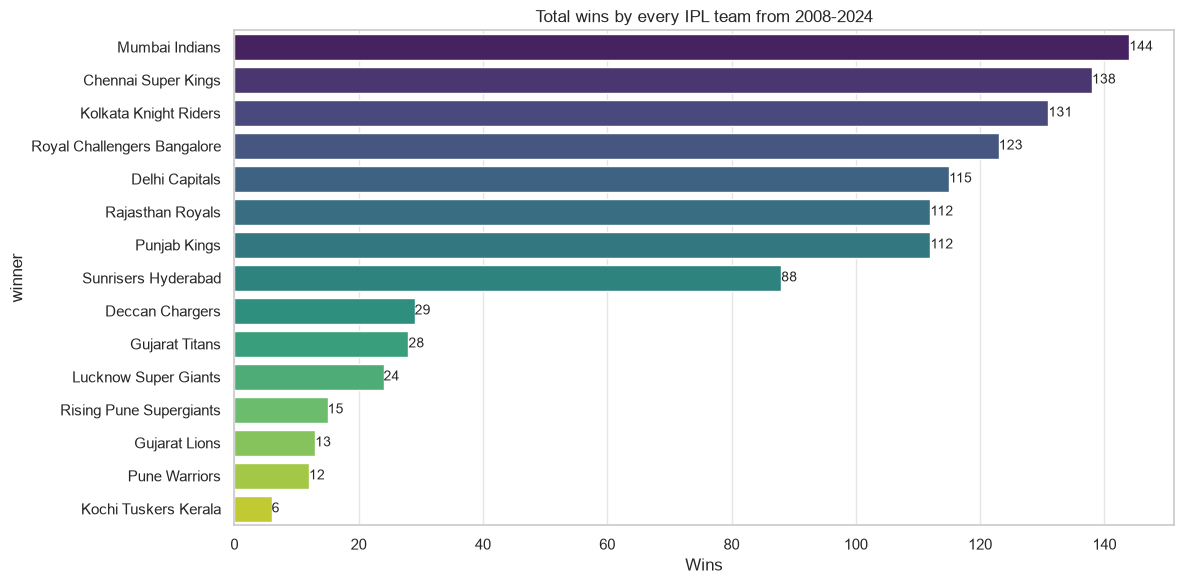

In [2]:
valid = match[match['winner'].notna()]

wins = valid['winner'].value_counts()
plt.figure(figsize =(12,6))
ax = sns.barplot(x=wins.values, y= wins.index, palette='viridis', hue = wins.index, legend = False)
for container in ax.containers:
    ax.bar_label(container, fontsize=10)
plt.title("Total wins by every IPL team from 2008-2024")
plt.xlabel("Wins")
plt.tight_layout()
plt.savefig("team_wins.png")
plt.show()

**Observations:**
- Mumbai Indians leads with 144 wins, followed by Chennai Super Kings and Kolkata Knight Riders
- Surprising: Chennai Super Kings is on 2nd position in total matches won even though they played 2 seasons(2016 and 2017) less then the rest of top 8 teams

## 3. Toss Analysis
Does winning the toss actually help you win the match? And does the bat/field
decision matter?

In [3]:
# Does winning toss = winning match?
valid['toss_won_match'] = valid['toss_winner'] == valid['winner']
toss_win_pct = valid['toss_won_match'].mean() * 100
print(f"Toss winners won the match {toss_win_pct:.1f}% of the time")

# Bat vs field decision
decision = valid.groupby('toss_decision')['toss_won_match'].mean() * 100
print(decision)

Toss winners won the match 50.8% of the time
toss_decision
bat      45.384615
field    53.857143
Name: toss_won_match, dtype: float64


**Findings:**
- Toss winners went on to win 50.8% of matches — which not same as coin flip, so toss is not a strong predictor on its own
- Teams that chose to bat after winning the toss won had a 7% more chance of winning the match then the team that choose to bowl.

## 4. Toss Impact by Venue
Toss advantage isn't uniform — some grounds favour chasing, others favour setting a
target. Restricting to venues with 20+ matches for statistical reliability.

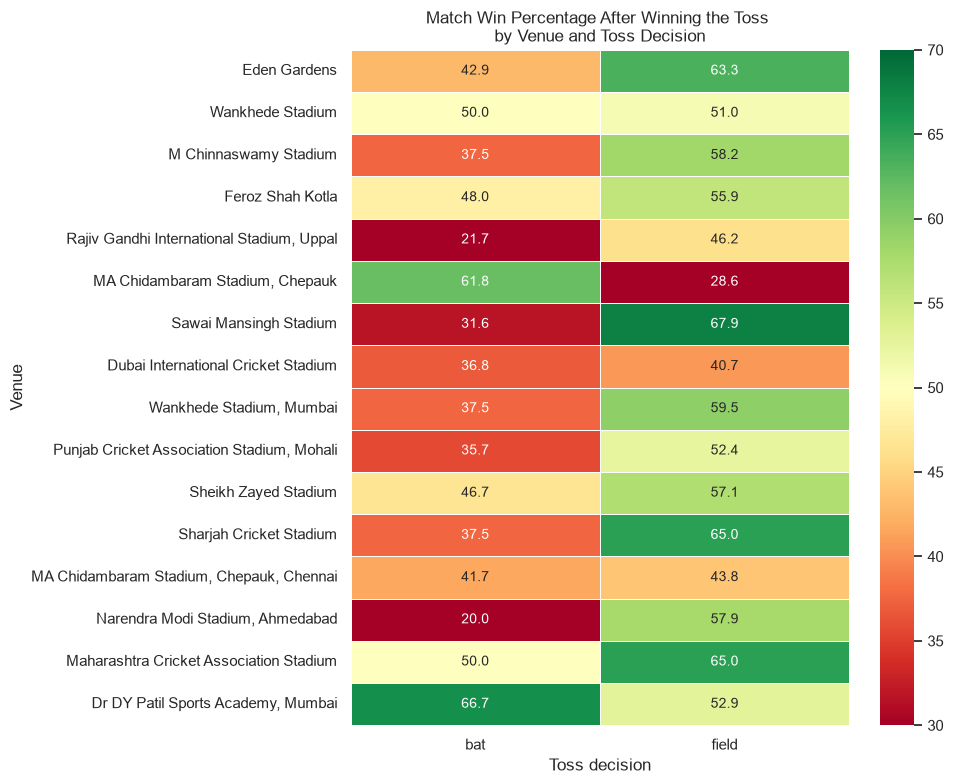

In [4]:
venue_counts = valid['venue'].value_counts()
top_venues = venue_counts[venue_counts >= 20].index

venue_toss = (valid[valid['venue'].isin(top_venues)]
              .groupby(['venue', 'toss_decision'])['toss_won_match']
              .mean()
              .mul(100)
              .round(1)
              .unstack()
              .loc[top_venues]
)

plt.figure(figsize=(10, 8))
sns.heatmap(venue_toss, annot=True, fmt='.1f',
            cmap='RdYlGn', center=50, vmin=30, vmax=70,
            linewidths=0.5, annot_kws={"fontsize":10})
plt.title('Match Win Percentage After Winning the Toss \nby Venue and Toss Decision')
plt.xlabel("Toss decision")
plt.ylabel("Venue")
plt.tight_layout()
plt.savefig('toss_venue_heatmap.png')
plt.show()

**Observations:**
- At Sawai Mansingh Stadium, winning toss and choosing to field led to a match win 67.9% of the time
  — one of the strongest venue biases in the dataset
- At Dr DY Patil Sports Academy(Mumbai), the opposite holds: batting first after winning toss wins 66.7% of the time
- Wankhede Stadium shows almost no toss advantage either way (~50%), suggesting the pitch/ground
  size neutralises the toss decision

## 5. Win Margins
How dominant are typical wins — narrow finishes or blowouts? Comparing run-margin
wins (defending) vs wicket-margin wins (chasing).

result
wickets    578
runs       498
tie         14
Name: count, dtype: int64


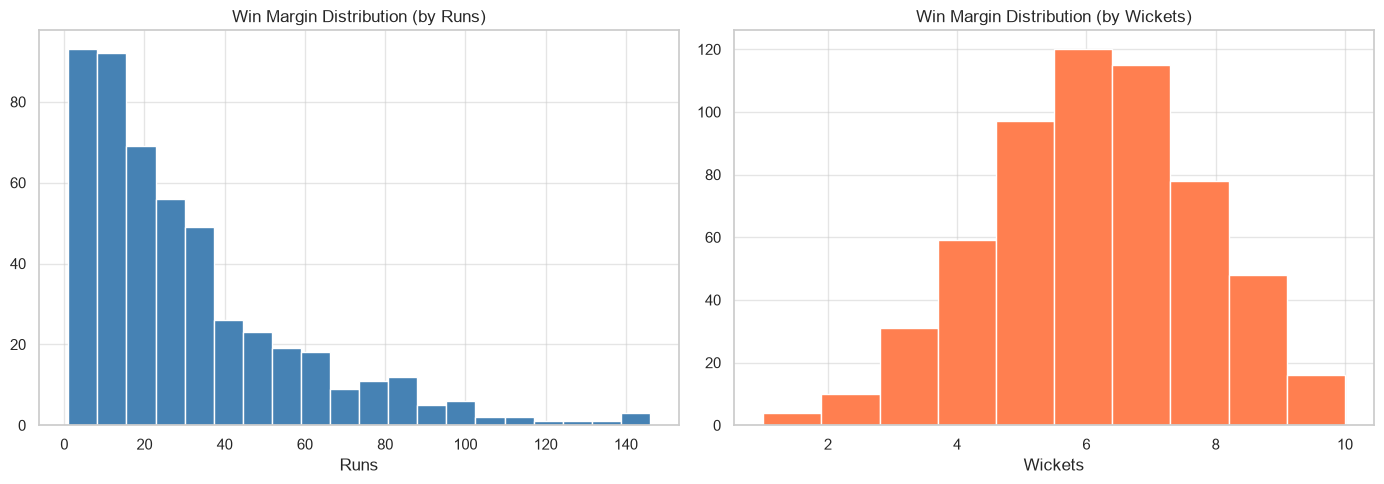

 season                       team1                 team2                      winner result  result_margin
   2017              Delhi Capitals        Mumbai Indians              Mumbai Indians   runs          146.0
   2016 Royal Challengers Bangalore         Gujarat Lions Royal Challengers Bangalore   runs          144.0
   2007 Royal Challengers Bangalore Kolkata Knight Riders       Kolkata Knight Riders   runs          140.0
   2015 Royal Challengers Bangalore          Punjab Kings Royal Challengers Bangalore   runs          138.0
   2013 Royal Challengers Bangalore         Pune Warriors Royal Challengers Bangalore   runs          130.0


In [5]:
# Wins by runs vs wins by wickets
result_type = valid['result'].value_counts()
print(result_type)

# Distribution of margins
runs_wins = valid[valid['result'] == 'runs']['result_margin']
wicket_wins = valid[valid['result'] == 'wickets']['result_margin']
runs_wins

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(runs_wins, bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Win Margin Distribution (by Runs)')
axes[0].set_xlabel('Runs')

axes[1].hist(wicket_wins, bins=10, color='coral', edgecolor='white')
axes[1].set_title('Win Margin Distribution (by Wickets)')
axes[1].set_xlabel('Wickets')
plt.tight_layout()
plt.show()

# Top 5 most dominant wins
print(
    valid.nlargest(5, 'result_margin')[
        ['season', 'team1', 'team2', 'winner', 'result', 'result_margin']
    ].to_string(index=False)
)


**Observations:**
- Most run-margin wins cluster between 0-20 runs — truly dominant wins (50+ runs)
  are rare
- Wicket-margin wins skew toward 6-7 wickets, meaning chasing teams typically
  finish comfortably rather than in last-over finishes
- The most dominant win ever was by Mumbai Indians beating Delhi Capitals by 146 runs in 2017

## 6. Player of the Match Leaders
Who shows up most often as the standout performer across IPL history?

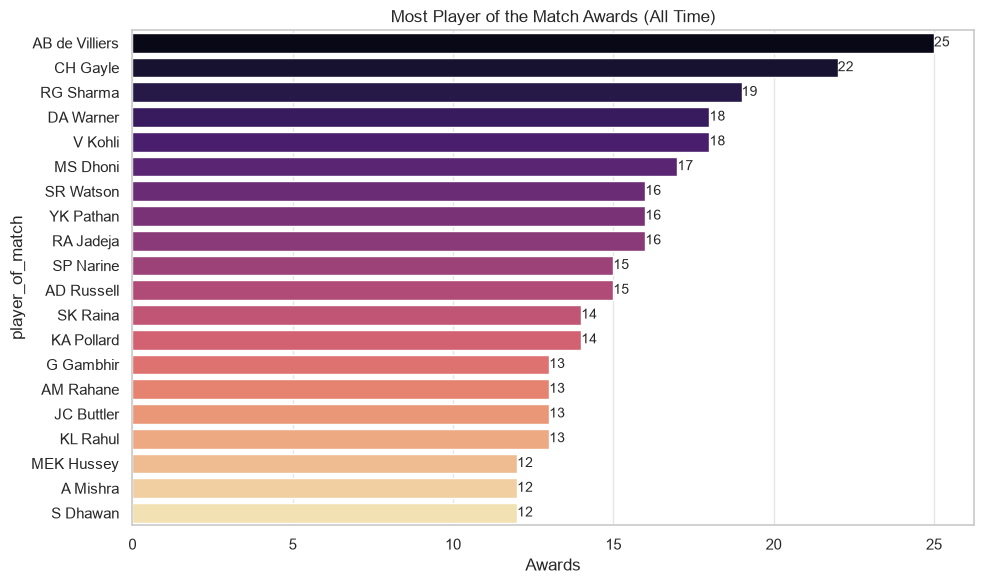

In [6]:
potm = valid['player_of_match'].value_counts().head(20)
plt.figure(figsize=(10,6))
bx = sns.barplot(x=potm.values, y=potm.index, palette='magma', hue = potm.index, legend=False)
for container in bx.containers:
    bx.bar_label(container, fontsize = 10)
plt.title('Most Player of the Match Awards (All Time)')
plt.xlabel('Awards')
plt.tight_layout()
plt.show()

**Observations:**
- AB de Villiers leads all-time with 25 awards, reflecting 14 consistent seasons
- The top 20 is dominated by Batters/All rounders, with only 1 specialist bowler
  making the list — POTM awards skew toward batting performances.

## Key Findings

1. Mumbai Indians is the most successful IPL franchise by win count, while franchises that
   were rebranded/discontinued (e.g. Deccan Chargers) show a visible dip.
2. Winning the toss doesn't make any difference in the result of the match.
3. Toss advantage is highly venue-dependent: Sawai Mansingh Stadium rewards fielding first,
   Dr DY Patil Sports Academy(Mumbai) rewards batting first.
4. Most wins are moderate, not blowouts — dominant 50+ run wins or extremely close
   1-wicket finishes are both rare.
5. Player of the Match awards are batting-heavy, showing IPL's format rewards
   explosive individual batting performances more than bowling spells.